Name: Rushikesh Anil Khairnar  
Student: 5115301  
Roll NO: 21  
College: B. K. Birla College

# **Practical 10: End-to-End Data Engineering Mini Project**
This comprehensive, standalone mini-project fulfills the requirements of Practical 10. While originally designed for a group of two, this scope has been expanded and adapted for a single developer to showcase a complete Data Engineering lifecycle.   


**The project simulates a retail company's pipeline. It includes:**  
**1.Data Ingestion:** Reading from diverse sources (CSV and JSON).  
**2.Data Cleaning & Transformation:** Handling missing values, standardizing dates, and calculating derived metrics.  
**3.Data Warehouse Design:** Implementing a Star Schema (Fact and Dimension tables).   
**4.Storage:** Loading the transformed data into a relational SQLite database.  
**5.Reporting:** Querying the warehouse to generate a business report and a data visualization.

# **Complete Project Code**
It is completely self-contained; it will generate the necessary dummy raw data, process it through the entire pipeline, build the database, and output the final reports.


=== STARTING END-TO-END DATA ENGINEERING PIPELINE ===

[Phase 0] Generating simulated raw data (CSVs and JSON)...

[Phase 1] Extracting data from multiple sources...

[Phase 2] Cleaning and Transforming data...
  -> Dropped 2 invalid transaction records.

[Phase 3] Loading Star Schema into SQLite Data Warehouse...
  -> Successfully loaded 4 records into fact_sales.

[Phase 4] Generating Business Reports from Data Warehouse...

--- REPORT 1: Revenue by Category ---
   category  items_sold  total_revenue
Electronics           4         2450.0
  Furniture           2          301.0

--- REPORT 2: Top Customers ---
  full_name region  lifetime_value
Alice Smith  North          1250.0
Eve Unknown  North          1200.0
  Bob Jones  South           301.0

  -> Visualization saved locally as 'revenue_report_chart.png'

=== PIPELINE EXECUTION COMPLETE ===


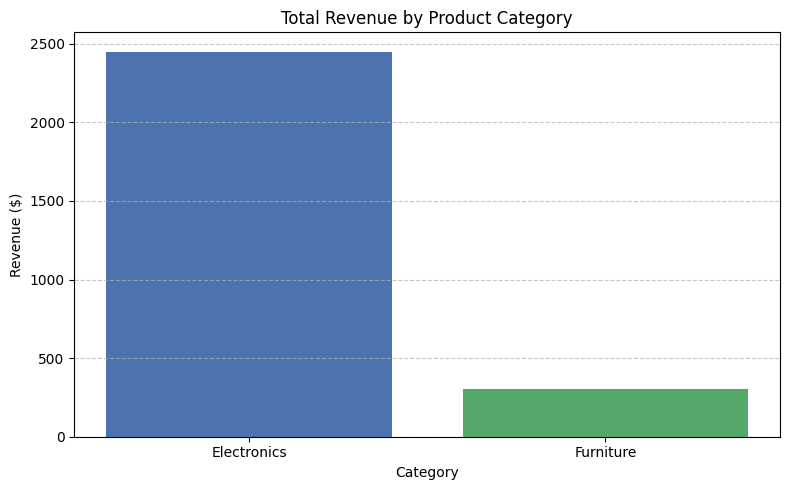

In [1]:
import pandas as pd
import sqlite3
import json
import os
import matplotlib.pyplot as plt

print("=== STARTING END-TO-END DATA ENGINEERING PIPELINE ===")

# ==========================================
# PHASE 0: SETUP & RAW DATA GENERATION
# ==========================================
print("\n[Phase 0] Generating simulated raw data (CSVs and JSON)...")

# 1. Customers Data (CSV)
customers_data = """customer_id,first_name,last_name,region
1,Alice,Smith,North
2,Bob,Jones,South
3,Charlie,Brown,East
4,Diana,Prince,West
5,Eve,,North""" # Intentional missing last name
with open("raw_customers.csv", "w") as f:
    f.write(customers_data)

# 2. Products Data (JSON)
products_data = [
    {"product_id": 101, "product_name": "Laptop", "category": "Electronics", "price": 1200.00},
    {"product_id": 102, "product_name": "Desk Chair", "category": "Furniture", "price": 150.50},
    {"product_id": 103, "product_name": "Mouse", "category": "Electronics", "price": 25.00},
    {"product_id": 104, "product_name": "Notebook", "category": "Stationery", "price": 5.00}
]
with open("raw_products.json", "w") as f:
    json.dump(products_data, f)

# 3. Transactions Data (CSV) - Contains anomalies (missing dates, negative qty)
transactions_data = """tx_id,date,customer_id,product_id,quantity
1001,2026-10-01,1,101,1
1002,2026-10-02,2,102,2
1003,,3,103,1
1004,2026-10-02,1,103,2
1005,2026-10-03,4,104,-5
1006,2026-10-04,5,101,1"""
with open("raw_transactions.csv", "w") as f:
    f.write(transactions_data)


# ==========================================
# PHASE 1: DATA INGESTION (EXTRACTION)
# ==========================================
print("\n[Phase 1] Extracting data from multiple sources...")
df_customers = pd.read_csv("raw_customers.csv")
df_products = pd.read_json("raw_products.json")
df_transactions = pd.read_csv("raw_transactions.csv")


# ==========================================
# PHASE 2: DATA CLEANING & TRANSFORMATION
# ==========================================
print("\n[Phase 2] Cleaning and Transforming data...")

# Clean Customers: Fill missing last names, create full name
df_customers['last_name'] = df_customers['last_name'].fillna("Unknown")
df_customers['full_name'] = df_customers['first_name'] + " " + df_customers['last_name']
df_customers = df_customers[['customer_id', 'full_name', 'region']] # Select final columns

# Clean Transactions: Remove invalid rows
initial_tx_count = len(df_transactions)
df_transactions = df_transactions.dropna(subset=['date']) # Drop missing dates
df_transactions = df_transactions[df_transactions['quantity'] > 0] # Remove negative quantities
print(f"  -> Dropped {initial_tx_count - len(df_transactions)} invalid transaction records.")

# Transformation: Derive Date Dimension elements
df_transactions['date'] = pd.to_datetime(df_transactions['date'])
df_date_dim = pd.DataFrame({
    'date_id': df_transactions['date'].dt.strftime('%Y%m%d').astype(int),
    'full_date': df_transactions['date'].dt.date,
    'year': df_transactions['date'].dt.year,
    'month': df_transactions['date'].dt.month,
    'day': df_transactions['date'].dt.day
}).drop_duplicates()

# Transformation: Map date_id back to transactions and calculate Total Sales Amount
df_transactions['date_id'] = df_transactions['date'].dt.strftime('%Y%m%d').astype(int)
df_transactions = df_transactions.merge(df_products[['product_id', 'price']], on='product_id', how='left')
df_transactions['total_amount'] = df_transactions['quantity'] * df_transactions['price']

# Prepare Final Fact Table
df_fact_sales = df_transactions[['tx_id', 'date_id', 'customer_id', 'product_id', 'quantity', 'total_amount']]


# ==========================================
# PHASE 3: DATA WAREHOUSE DESIGN & STORAGE
# ==========================================
print("\n[Phase 3] Loading Star Schema into SQLite Data Warehouse...")
db_name = "enterprise_data_warehouse.db"
conn = sqlite3.connect(db_name)

# Load Dimensions
df_customers.to_sql("dim_customer", conn, if_exists="replace", index=False)
df_products.to_sql("dim_product", conn, if_exists="replace", index=False)
df_date_dim.to_sql("dim_date", conn, if_exists="replace", index=False)

# Load Fact
df_fact_sales.to_sql("fact_sales", conn, if_exists="replace", index=False)
print(f"  -> Successfully loaded {len(df_fact_sales)} records into fact_sales.")


# ==========================================
# PHASE 4: REPORTING & VISUALIZATION
# ==========================================
print("\n[Phase 4] Generating Business Reports from Data Warehouse...")

# Report 1: Sales by Category (SQL JOIN across Star Schema)
query_sales_by_category = """
    SELECT
        p.category,
        SUM(f.quantity) as items_sold,
        SUM(f.total_amount) as total_revenue
    FROM fact_sales f
    JOIN dim_product p ON f.product_id = p.product_id
    GROUP BY p.category
    ORDER BY total_revenue DESC
"""
df_report1 = pd.read_sql(query_sales_by_category, conn)
print("\n--- REPORT 1: Revenue by Category ---")
print(df_report1.to_string(index=False))

# Report 2: Top Customers by Region
query_top_customers = """
    SELECT
        c.full_name,
        c.region,
        SUM(f.total_amount) as lifetime_value
    FROM fact_sales f
    JOIN dim_customer c ON f.customer_id = c.customer_id
    GROUP BY c.full_name, c.region
    ORDER BY lifetime_value DESC
"""
df_report2 = pd.read_sql(query_top_customers, conn)
print("\n--- REPORT 2: Top Customers ---")
print(df_report2.to_string(index=False))

# Visualization: Bar Chart of Sales by Category
plt.figure(figsize=(8, 5))
plt.bar(df_report1['category'], df_report1['total_revenue'], color=['#4C72B0', '#55A868'])
plt.title('Total Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
chart_filename = "revenue_report_chart.png"
plt.savefig(chart_filename)
print(f"\n  -> Visualization saved locally as '{chart_filename}'")


# ==========================================
# CLEANUP
# ==========================================
conn.close()
os.remove("raw_customers.csv")
os.remove("raw_products.json")
os.remove("raw_transactions.csv")
print("\n=== PIPELINE EXECUTION COMPLETE ===")

In [2]:
# Optional: Export Star Schema to CSV for Power BI / Tableau
df_fact_sales.to_csv("fact_sales.csv", index=False)
df_customers.to_csv("dim_customer.csv", index=False)
df_products.to_csv("dim_product.csv", index=False)
df_date_dim.to_csv("dim_date.csv", index=False)
print("  -> Exported Star Schema to CSV for BI Tools.")

  -> Exported Star Schema to CSV for BI Tools.


# **Key Architectural Concepts Addressed**
**Data Ingestion:** Handled mixed formats (CSV & JSON) and standardized them into Pandas DataFrames.

**Data Cleaning:** Removed corrupted transactions (null dates, negative quantities) and handled missing customer strings.

**Data Warehouse Design (Star Schema):** Modeled the data into a central fact_sales table surrounded by dim_customer, dim_product, and dim_date tables. This allows for highly optimized analytical querying.

**Storage:** Utilized an embedded SQLite database (enterprise_data_warehouse.db) to persist the architecture.

# **Power BI DashBoard**

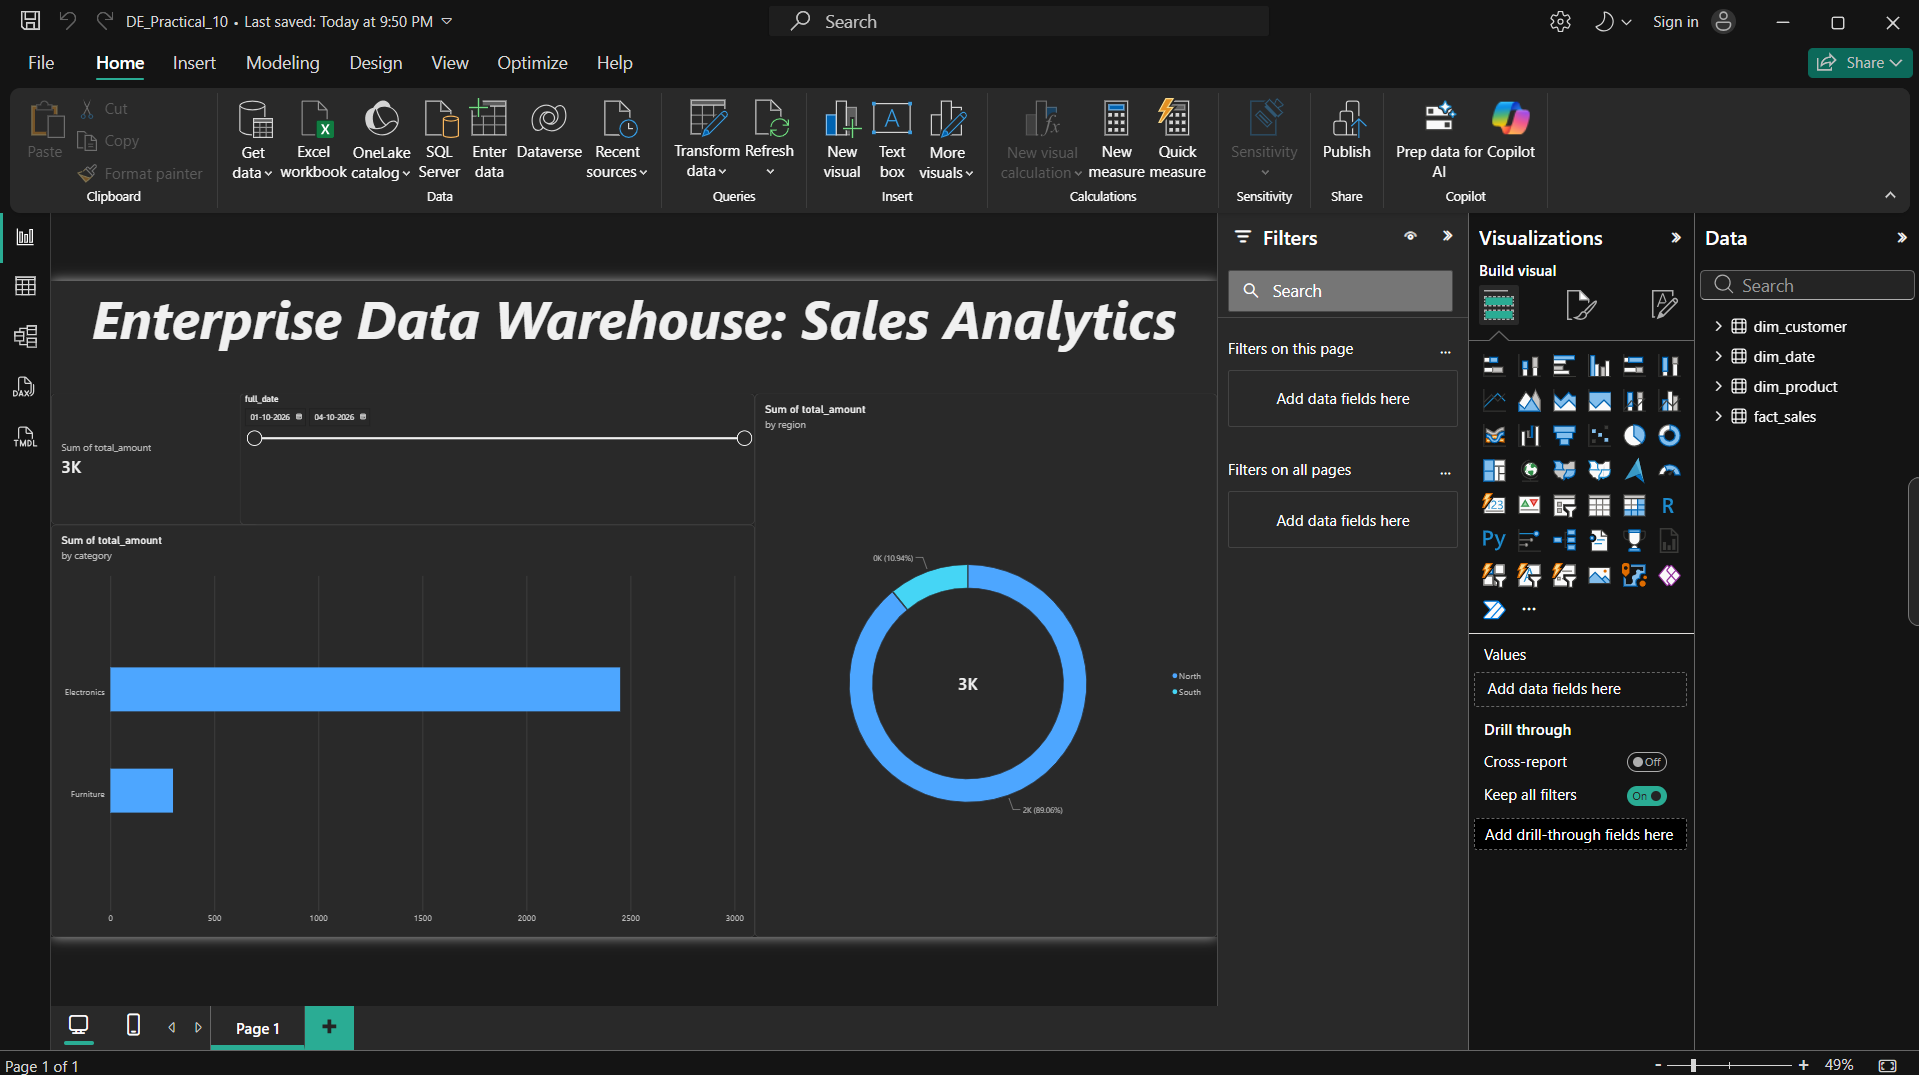